In [62]:
import numpy as np
import cmath
import matplotlib.pyplot as plt
import pde
from pde import DiffusionPDE, CartesianGrid, ScalarField, FieldCollection, MemoryStorage

In [63]:
L = 10.0
k = 2.0
grid = CartesianGrid([(-L, L)], 128, periodic=[False])

x = grid.axes_coords[0]  # x-coordinates of the grid points
x0 = -6.0  # x0 < 0
sigma = 0.8

# Initial Condition
gaussian = np.exp(-((x - x0)**2) / (2*(sigma)**2))  #gaussian term 
plane_re = np.cos(k*x) * gaussian  #real part of the plane wave
plane_im = np.sin(k*x) * gaussian  #imaginary part of the plane wave

# Normalizing Initial Condition
rho0 = plane_re**2 + plane_im**2
norm0 = np.trapz(rho0, x)
plane_re = plane_re / np.sqrt(norm0)
plane_im = plane_im / np.sqrt(norm0)

initial_cond_re = ScalarField(grid, plane_re)   #real part of the initial condition
initial_cond_im = ScalarField(grid, plane_im)   #imaginary part of the initial condition

state = FieldCollection([initial_cond_re, initial_cond_im], labels=["u", "v"])  #combine real and imaginary parts into a FieldCollection

In [64]:
# Boundary Conditions
k = 2.0
L = 10.0
hbar = 1.0  #scaled units for quantum PDE simulations
m = 1.0
omega = hbar * k**2 / (2 * m)
t = 20.0

# psi = lambda k,x : np.exp(1j * (k*x))  # plane wave solution, ref (1.1)

# old stuff
# # Real parts of Dirichlet and Robin
# bc_u = {"x-": {"value_expression": f"cos({k}*x - {omega}*t)"}, "x+": {"derivative": f"-{k} * v"}}  # Dirichlet at x=-L, Neumann at x=L

# # Imaginary parts of Dirichlet and Robin
# bc_v = {"x-": {"value_expression": f"sin({k}*x - {omega}*t)"}, "x+": {"derivative": f"{k} * u"}}  # Dirichlet at x=-L, Neumann at x=L

# new stuff
# BC operations combining parts of Dirichlet and Robin
bc = {
    "x-": {"derivative": 0},
    "x+": {"derivative": 0},
}

In [65]:
dx = x[1] - x[0]

def hook(state_data, t):
    u = state_data[0]
    v = state_data[1]

    # -------------------------
    # left boundary: Dirichlet
    # -------------------------
    theta = -k*L - omega*t
    u[0] = u[1]
    v[0] = v[1]

    # -------------------------
    # right boundary: coupled Robin
    # u_x = -k v
    # v_x =  k u
    # -------------------------
    c = dx * k
    denom = 1 + c**2

    u_in = u[-2]
    v_in = v[-2]

    u[-1] = (u_in - c*v_in) / denom
    v[-1] = (v_in + c*u_in) / denom

In [66]:
# Smoothed out Potential energy conditions for Interfaces

x_vals = np.linspace(-L, L, 1000)
a = 2.0  # width of the potential barrier
alpha = 20.0  # controls the steepness of the transition
v0 = 10.0  # height of the potential barrier

v_smooth = lambda x_vals, v0, a, alpha: 0.5 * v0 * (np.tanh(alpha * x_vals) - np.tanh(alpha * (x_vals-a))) 

In [67]:
# Governing equation / PDE

v_str = f"0.5 * {v0} * (tanh({alpha} * x) - tanh({alpha} * (x-{a})))"
# eq = pde.PDE({"psi": f"I * {hbar/(2*m)} * laplace(psi) - I / {hbar} * ({v_str}) * psi"})

eq = pde.PDE({
    "u": f"-( {hbar/(2*m)} ) * laplace(v) + ( ({v_str}) / {hbar} ) * v",
    "v": f"( {hbar/(2*m)} ) * laplace(u) - ( ({v_str}) / {hbar} ) * u"
}, bc = bc, post_step_hook=hook)

In [68]:
# result = eq.solve(state, t_range=t)
storage = MemoryStorage()
result = eq.solve(
    state,
    t_range=t,
    dt=1e-5,
    tracker=storage.tracker(0.1)
)

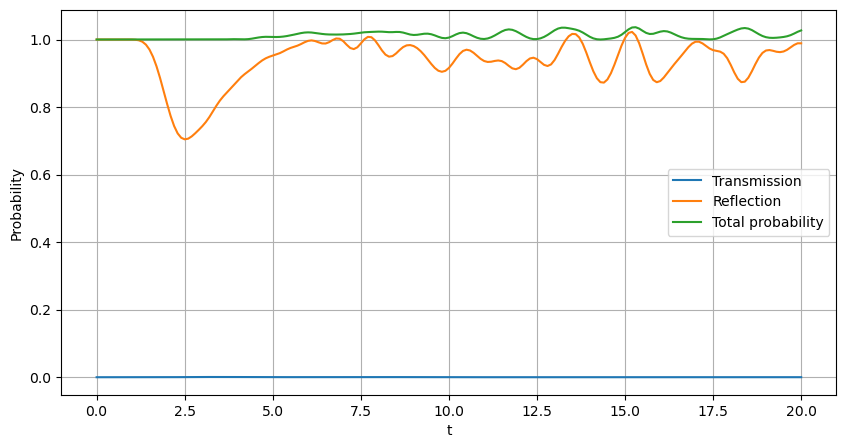

Final T = 0.0001035671685386843
Final R = 0.9887067295561669
Final N = 1.026956986879961
Peak T = 0.0007113444675432623
Peak R = 1.0224349476877896
Peak N = 1.0363738598807204


In [69]:
def probability_density(fields):
    u = fields[0].data
    v = fields[1].data
    return u**2 + v**2

def transmission_probability(fields, x, barrier_right_edge):
    rho = probability_density(fields)
    mask = x > barrier_right_edge + 0.5    # shift slightly right
    return np.trapz(rho[mask], x[mask])

def reflection_probability(fields, x, barrier_left_edge=0.0):
    rho = probability_density(fields)
    mask = x < barrier_left_edge - 0.5     # shift slightly left
    return np.trapz(rho[mask], x[mask])

def total_probability(fields, x):
    rho = probability_density(fields)
    return np.trapz(rho, x)

times, Tvals, Rvals, Nvals = [], [], [], []

for time, fields in storage.items():
    times.append(time)
    Tvals.append(transmission_probability(fields, x, a))
    Rvals.append(reflection_probability(fields, x, 0.0))
    Nvals.append(total_probability(fields, x))

plt.figure(figsize=(10, 5))
plt.plot(times, Tvals, label="Transmission")
plt.plot(times, Rvals, label="Reflection")
plt.plot(times, Nvals, label="Total probability")
plt.xlabel("t")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.savefig("transmission,reflection,total prob curves.pdf", bbox_inches="tight")
plt.show()

print("Final T =", Tvals[-1])
print("Final R =", Rvals[-1])
print("Final N =", Nvals[-1])
print("Peak T =", Tvals[np.argmax(Tvals)])
print("Peak R =", Rvals[np.argmax(Rvals)])
print("Peak N =", Nvals[np.argmax(Nvals)])

In [70]:
def barrier_probability(fields, x, a):
    rho = probability_density(fields)
    mask = (x >= 0) & (x <= a)
    return np.trapz(rho[mask], x[mask])

Bvals = []

for time, fields in storage.items():
    Bvals.append(barrier_probability(fields, x, a))

print("Final Sum of probabilities (T + R + B) =", Tvals[-1] + Rvals[-1] + Bvals[-1])
print("Final Total Probability (N) =", Nvals[-1])
print("Sum of probabilities (T + R + B) at Peak T =", Tvals[np.argmax(Tvals)] + Rvals[np.argmax(Tvals)] + Bvals[np.argmax(Tvals)])
print("Total Probability (N) at Peak T =", Nvals[np.argmax(Tvals)])

Final Sum of probabilities (T + R + B) = 0.9942369410550475
Final Total Probability (N) = 1.026956986879961
Sum of probabilities (T + R + B) at Peak T = 0.826672063534337
Total Probability (N) at Peak T = 1.0003139450490945


In [71]:
a_values = np.linspace(1.0, 5.0, 20)
T_final = []
V0 = 10.0

for a_val in a_values:

    # recreate initial condition each time
    gaussian = np.exp(-((x - x0)**2) / (2*sigma**2))
    u_init = np.cos(k*x) * gaussian
    v_init = np.sin(k*x) * gaussian

    rho0 = u_init**2 + v_init**2
    norm0 = np.sum(rho0) * dx
    u_init /= np.sqrt(norm0)
    v_init /= np.sqrt(norm0)

    u_field = ScalarField(grid, u_init)
    v_field = ScalarField(grid, v_init)

    state = FieldCollection([u_field, v_field], labels=["u", "v"])

    # update barrier
    v_str = f"0.5 * {V0} * (tanh({alpha} * x) - tanh({alpha} * (x-{a_val})))"

    eq = pde.PDE({
        "u": f"-( {hbar/(2*m)} ) * laplace(v) + (({v_str})/{hbar}) * v",
        "v": f"( {hbar/(2*m)} ) * laplace(u) - (({v_str})/{hbar}) * u"
    }, bc=bc, post_step_hook=hook)

    result = eq.solve(state, t_range=t, dt=1e-5)

    # compute transmission at final time
    u = result["u"].data
    v = result["v"].data
    rho = u**2 + v**2

    T_val = np.sum(rho[x > a_val]) * dx
    T_final.append(T_val)

  0%|          | 0/20.0 [00:00<?, ?it/s]

  0%|          | 0/20.0 [00:00<?, ?it/s]

  0%|          | 0/20.0 [00:00<?, ?it/s]

  0%|          | 0/20.0 [00:00<?, ?it/s]

  0%|          | 0/20.0 [00:00<?, ?it/s]

...

  0%|          | 0/20.0 [00:00<?, ?it/s]

  0%|          | 0/20.0 [00:00<?, ?it/s]

  0%|          | 0/20.0 [00:00<?, ?it/s]

  0%|          | 0/20.0 [00:00<?, ?it/s]

  0%|          | 0/20.0 [00:00<?, ?it/s]

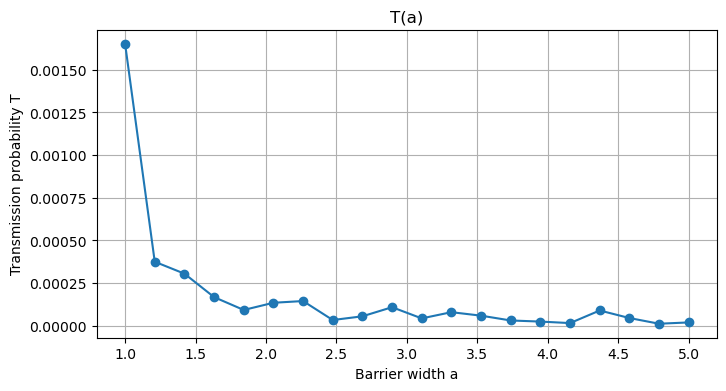

In [72]:
plt.figure(figsize=(8,4))
plt.plot(a_values, T_final, 'o-')
plt.xlabel("Barrier width a")
plt.ylabel("Transmission probability T")
plt.title("T(a)")
plt.grid(True)
plt.savefig("barrier_width vs transmission prob.pdf", bbox_inches="tight")
plt.show()

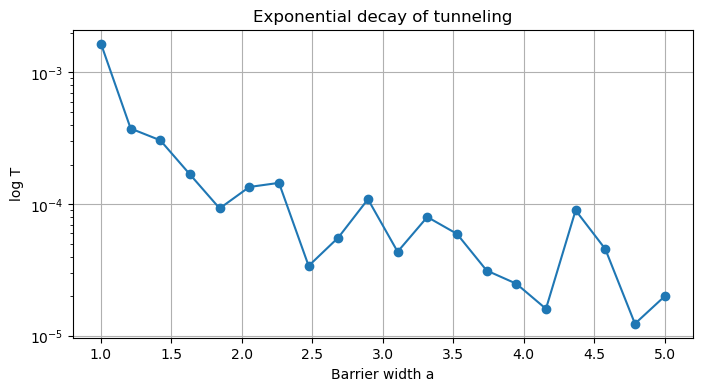

In [73]:
plt.figure(figsize=(8,4))
plt.semilogy(a_values, T_final, 'o-')
plt.xlabel("Barrier width a")
plt.ylabel("log T")
plt.title("Exponential decay of tunneling")
plt.grid(True)
plt.savefig("exponential_decay.pdf", bbox_inches="tight")
plt.show()

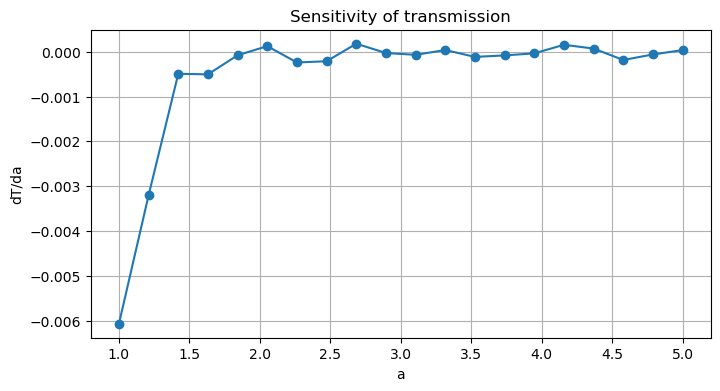

In [74]:
dT_da = np.gradient(T_final, a_values)

plt.figure(figsize=(8,4))
plt.plot(a_values, dT_da, 'o-')
plt.xlabel("a")
plt.ylabel("dT/da")
plt.title("Sensitivity of transmission")
plt.grid(True)
plt.savefig("sensitivity_of_transmission.pdf", bbox_inches="tight")
plt.show()

In [75]:
a_values = np.linspace(1.0, 5.0, 20)
T_peak_vals = []
T_peak_times = []

V0 = 10.0
dt = 1e-5
tmax = 20.0
dtsave = 0.05   # save often enough to capture the peak

for a_val in a_values:
    # ----------------------------
    # 1. rebuild normalized IC
    # ----------------------------
    gaussian = np.exp(-((x - x0)**2) / (2 * sigma**2))
    u_init = np.cos(k * x) * gaussian
    v_init = np.sin(k * x) * gaussian

    rho0 = u_init**2 + v_init**2
    norm0 = np.trapz(rho0, x)
    u_init /= np.sqrt(norm0)
    v_init /= np.sqrt(norm0)

    u_field = ScalarField(grid, u_init, label="u")
    v_field = ScalarField(grid, v_init, label="v")
    state = FieldCollection([u_field, v_field])

    # ----------------------------
    # 2. rebuild barrier
    # ----------------------------
    v_str = f"0.5 * {V0} * (tanh({alpha} * x) - tanh({alpha} * (x-{a_val})))"

    eq = pde.PDE(
        {
            "u": f"-( {hbar/(2*m)} ) * laplace(v) + (({v_str})/{hbar}) * v",
            "v": f"( {hbar/(2*m)} ) * laplace(u) - (({v_str})/{hbar}) * u"
        },
        bc=bc,
        post_step_hook=hook
    )

    # ----------------------------
    # 3. solve and store snapshots
    # ----------------------------
    storage = MemoryStorage()
    result = eq.solve(
        state,
        t_range=tmax,
        dt=dt,
        tracker=storage.tracker(dtsave)
    )

    # ----------------------------
    # 4. compute T(t)
    # ----------------------------
    times = []
    Tvals = []

    for i in range(len(storage)):
        fields = storage[i]
        t_now = storage.times[i]

        u_now = fields[0].data
        v_now = fields[1].data
        rho_now = u_now**2 + v_now**2

        # transmitted mass to the right of the barrier
        T_now = np.trapz(rho_now[x > a_val], x[x > a_val])

        times.append(t_now)
        Tvals.append(T_now)

    # ----------------------------
    # 5. use peak transmission
    # ----------------------------
    i_peak = np.argmax(Tvals)
    T_peak_vals.append(Tvals[i_peak])
    T_peak_times.append(times[i_peak])

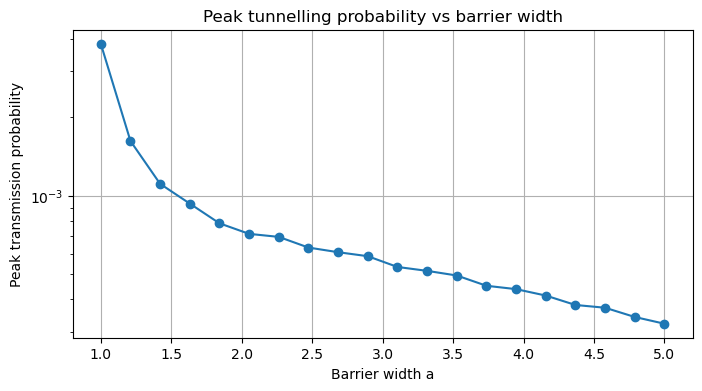

Peak times: [3.4000000000000075, 3.150000000000006, 3.150000000000006, 3.300000000000007, 3.4500000000000077, 3.500000000000008, 3.5500000000000083, 3.6000000000000085, 3.700000000000009, 3.8000000000000096, 3.85000000000001, 3.9500000000000104, 4.0500000000000105, 4.15000000000001, 4.20000000000001, 4.30000000000001, 4.450000000000009, 4.450000000000009, 4.550000000000009, 4.750000000000008]
Peak T values: [0.0038220921804210757, 0.0016197372077314072, 0.0011096989418383552, 0.0009321555075158706, 0.0007833310130400671, 0.0007136142429418971, 0.0006947928189688236, 0.0006323712976477216, 0.0006069575607598226, 0.0005859453665013134, 0.0005328652989210211, 0.0005147980340659184, 0.0004941498048384491, 0.00045132429802866145, 0.000438114349626717, 0.00041397985896765056, 0.00038097286435190714, 0.00037178522532882495, 0.00034265603427822267, 0.0003228699618278898]


In [76]:
# ----------------------------
# 6. plot
# ----------------------------
plt.figure(figsize=(8, 4))
plt.semilogy(a_values, T_peak_vals, 'o-')
plt.xlabel("Barrier width a")
plt.ylabel("Peak transmission probability")
plt.title("Peak tunnelling probability vs barrier width")
plt.grid(True)
plt.savefig("peak_tunnelling_probability vs barrier_width (semilogy).pdf", bbox_inches="tight")
plt.show()

print("Peak times:", T_peak_times)
print("Peak T values:", T_peak_vals)

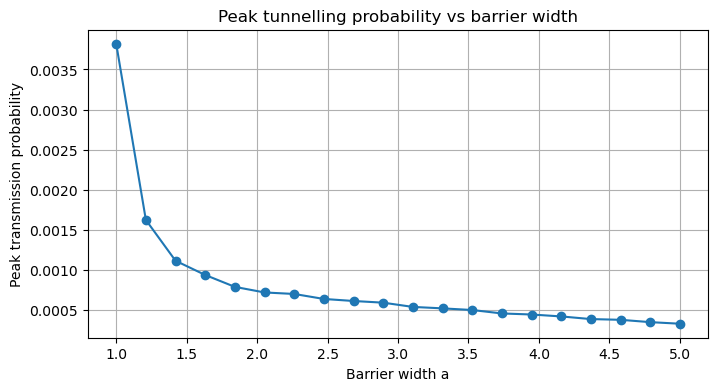

Peak times: [3.4000000000000075, 3.150000000000006, 3.150000000000006, 3.300000000000007, 3.4500000000000077, 3.500000000000008, 3.5500000000000083, 3.6000000000000085, 3.700000000000009, 3.8000000000000096, 3.85000000000001, 3.9500000000000104, 4.0500000000000105, 4.15000000000001, 4.20000000000001, 4.30000000000001, 4.450000000000009, 4.450000000000009, 4.550000000000009, 4.750000000000008]
Peak T values: [0.0038220921804210757, 0.0016197372077314072, 0.0011096989418383552, 0.0009321555075158706, 0.0007833310130400671, 0.0007136142429418971, 0.0006947928189688236, 0.0006323712976477216, 0.0006069575607598226, 0.0005859453665013134, 0.0005328652989210211, 0.0005147980340659184, 0.0004941498048384491, 0.00045132429802866145, 0.000438114349626717, 0.00041397985896765056, 0.00038097286435190714, 0.00037178522532882495, 0.00034265603427822267, 0.0003228699618278898]


In [77]:
plt.figure(figsize=(8, 4))
plt.plot(a_values, T_peak_vals, 'o-')
plt.xlabel("Barrier width a")
plt.ylabel("Peak transmission probability")
plt.title("Peak tunnelling probability vs barrier width")
plt.grid(True)
plt.savefig("peak_tunnelling_probability vs barrier_width.pdf", bbox_inches="tight")
plt.show()

print("Peak times:", T_peak_times)
print("Peak T values:", T_peak_vals)

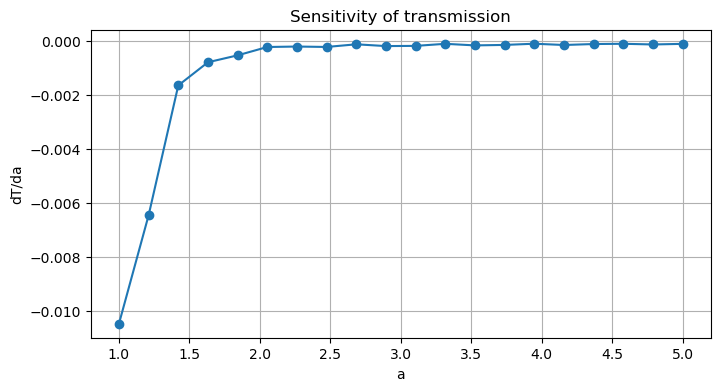

In [78]:
dT_da = np.gradient(T_peak_vals, a_values)

plt.figure(figsize=(8,4))
plt.plot(a_values, dT_da, 'o-')
plt.xlabel("a")
plt.ylabel("dT/da")
plt.title("Sensitivity of transmission")
plt.grid(True)
plt.savefig("sensitivity_of_transmission for peak.pdf", bbox_inches="tight")
plt.show()

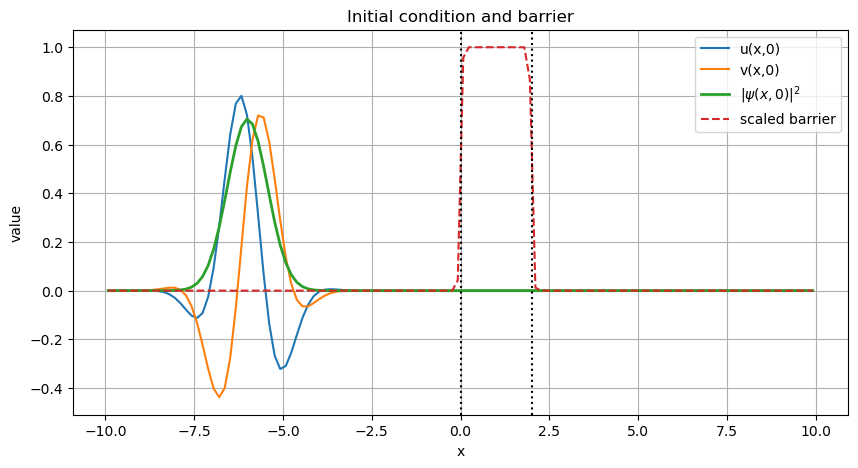

In [79]:
# ----- initial condition plot -----

rho0 = plane_re**2 + plane_im**2
Vx = 0.5 * v0 * (np.tanh(alpha * x) - np.tanh(alpha * (x - a)))

plt.figure(figsize=(10, 5))
plt.plot(x, plane_re, label="u(x,0)")
plt.plot(x, plane_im, label="v(x,0)")
plt.plot(x, rho0, label=r"$|\psi(x,0)|^2$", linewidth=2)
plt.plot(x, Vx / np.max(Vx), "--", label="scaled barrier")
plt.axvline(0, color="black", linestyle=":")
plt.axvline(a, color="black", linestyle=":")
plt.xlabel("x")
plt.ylabel("value")
plt.title("Initial condition and barrier")
plt.legend()
plt.grid(True)
plt.savefig("initial_condition_and_barrier.pdf", bbox_inches="tight")
plt.show()

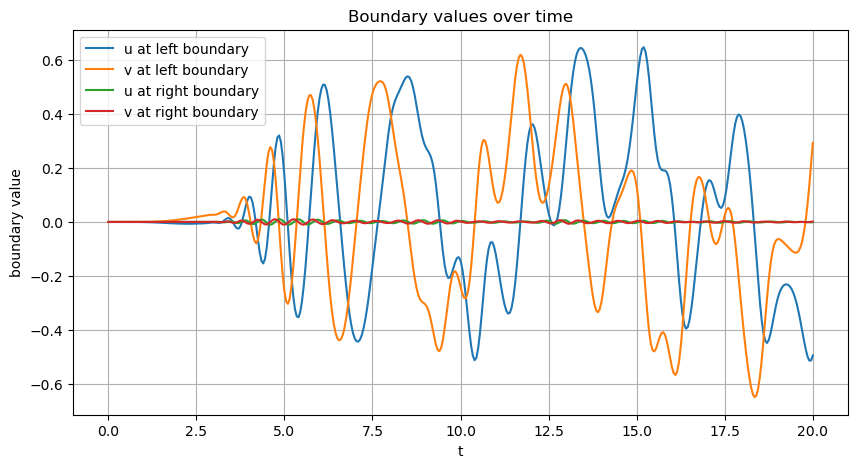

In [80]:
# ----- boundary values over time -----

times_bc = []
u_left_vals = []
v_left_vals = []
u_right_vals = []
v_right_vals = []

for time, fields in storage.items():
    u = fields[0].data
    v = fields[1].data

    times_bc.append(time)
    u_left_vals.append(u[0])
    v_left_vals.append(v[0])
    u_right_vals.append(u[-1])
    v_right_vals.append(v[-1])

plt.figure(figsize=(10, 5))
plt.plot(times_bc, u_left_vals, label="u at left boundary")
plt.plot(times_bc, v_left_vals, label="v at left boundary")
plt.plot(times_bc, u_right_vals, label="u at right boundary")
plt.plot(times_bc, v_right_vals, label="v at right boundary")
plt.xlabel("t")
plt.ylabel("boundary value")
plt.title("Boundary values over time")
plt.legend()
plt.grid(True)
plt.savefig("boundary_values_over_time.pdf", bbox_inches="tight")
plt.show()

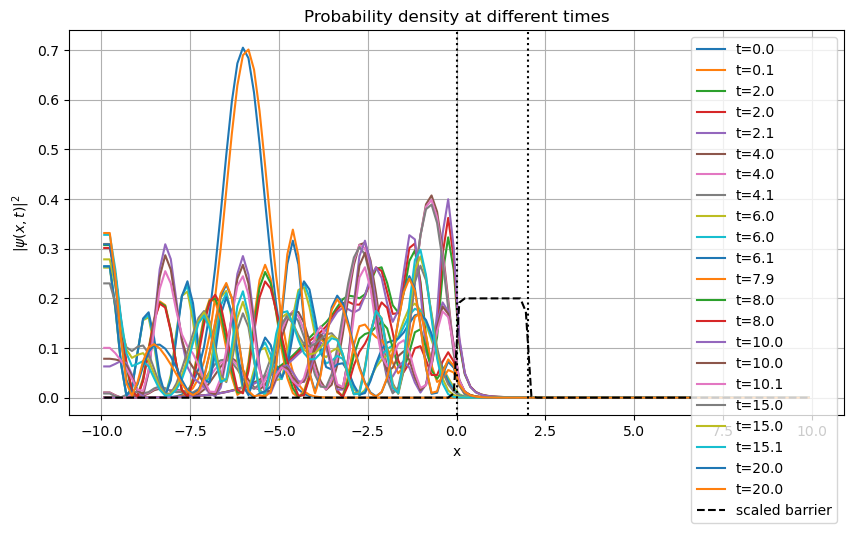

In [81]:
# ----- solution snapshots at different times -----

snapshot_times = [0, 2, 4, 6, 8, 10, 15, 20]

plt.figure(figsize=(10, 5))

for time, fields in storage.items():
    if np.min(np.abs(np.array(snapshot_times) - time)) < 0.06:
        rho = probability_density(fields)
        plt.plot(x, rho, label=f"t={time:.1f}")

plt.plot(x, Vx / np.max(Vx) * 0.2, "--", color="black", label="scaled barrier")
plt.axvline(0, color="black", linestyle=":")
plt.axvline(a, color="black", linestyle=":")
plt.xlabel("x")
plt.ylabel(r"$|\psi(x,t)|^2$")
plt.title("Probability density at different times")
plt.legend()
plt.grid(True)
plt.savefig("solution_snapshots(trajectories).pdf", bbox_inches="tight")
plt.show()

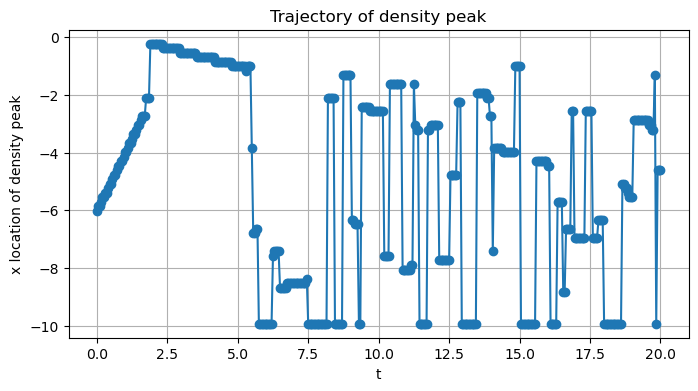

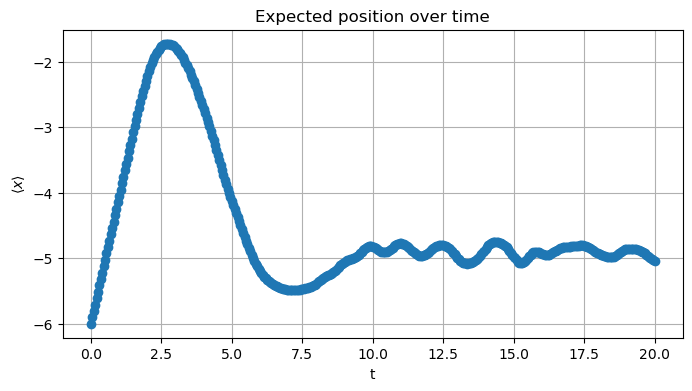

In [82]:
# ----- peak location trajectory -----

peak_x_vals = []

for time, fields in storage.items():
    rho = probability_density(fields)
    peak_x_vals.append(x[np.argmax(rho)])

plt.figure(figsize=(8, 4))
plt.plot(times, peak_x_vals, 'o-')
plt.xlabel("t")
plt.ylabel("x location of density peak")
plt.title("Trajectory of density peak")
plt.grid(True)
plt.savefig("density_peak_trajectory.pdf", bbox_inches="tight")
plt.show()

# ----- expected position trajectory -----

x_mean_vals = []

for time, fields in storage.items():
    rho = probability_density(fields)
    x_mean = np.trapz(x * rho, x) / np.trapz(rho, x)
    x_mean_vals.append(x_mean)

plt.figure(figsize=(8, 4))
plt.plot(times, x_mean_vals, 'o-')
plt.xlabel("t")
plt.ylabel(r"$\langle x \rangle$")
plt.title("Expected position over time")
plt.grid(True)
plt.savefig("expected_position_over_time.pdf", bbox_inches="tight")
plt.show()

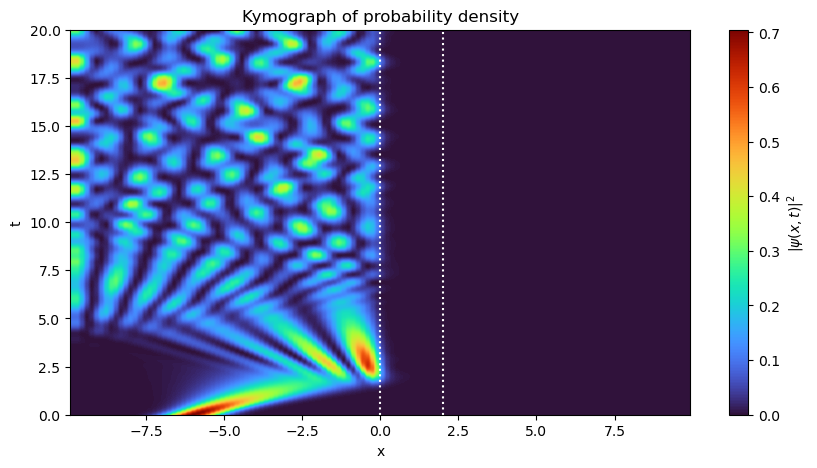

In [83]:
# ----- kymograph of probability density -----

rho_list = []
time_list = []

for time, fields in storage.items():
    rho_list.append(probability_density(fields))
    time_list.append(time)

rho_array = np.array(rho_list)
time_array = np.array(time_list)

plt.figure(figsize=(10, 5))
plt.imshow(
    rho_array,
    aspect="auto",
    origin="lower",
    extent=[x[0], x[-1], time_array[0], time_array[-1]],
    cmap="turbo"
)
plt.colorbar(label=r"$|\psi(x,t)|^2$")
plt.axvline(0, color="white", linestyle=":")
plt.axvline(a, color="white", linestyle=":")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Kymograph of probability density")
plt.savefig("kymograph_of_probability_density.pdf", bbox_inches="tight")
plt.show()

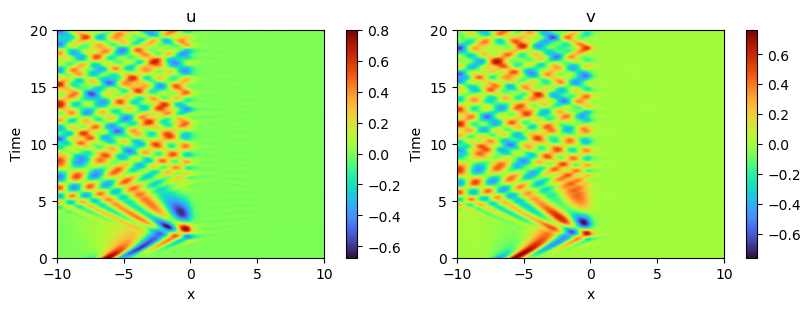

In [91]:
from pde import plot_kymographs

plot_kymographs(storage, cmap="turbo", filename="real&img_kymographs.pdf")
# plt.savefig("real&img_kymographs.pdf", bbox_inches="tight")

In [85]:
# ----- heatmap of T(a,t) -----

a_plot_values = np.linspace(1.0, 5.0, 20)
tmax = 20.0
dt = 1e-5
dtsave = 0.05

T_matrix = []
time_array = None

for a_val in a_plot_values:
    gaussian = np.exp(-((x - x0)**2) / (2 * sigma**2))
    u_init = np.cos(k * x) * gaussian
    v_init = np.sin(k * x) * gaussian

    rho0 = u_init**2 + v_init**2
    norm0 = np.trapz(rho0, x)
    u_init /= np.sqrt(norm0)
    v_init /= np.sqrt(norm0)

    u_field = ScalarField(grid, u_init)
    v_field = ScalarField(grid, v_init)
    state = FieldCollection([u_field, v_field], labels=["u", "v"])

    v_str = f"0.5 * {v0} * (tanh({alpha} * x) - tanh({alpha} * (x-{a_val})))"

    eq = pde.PDE({
        "u": f"-( {hbar/(2*m)} ) * laplace(v) + (({v_str})/{hbar}) * v",
        "v": f"( {hbar/(2*m)} ) * laplace(u) - (({v_str})/{hbar}) * u"
    }, bc=bc, post_step_hook=hook)

    storage_temp = MemoryStorage()
    eq.solve(state, t_range=tmax, dt=dt, tracker=storage_temp.tracker(dtsave))

    this_T = []
    this_times = []

    for time, fields in storage_temp.items():
        this_times.append(time)
        this_T.append(transmission_probability(fields, x, a_val))

    if time_array is None:
        time_array = np.array(this_times)

    T_matrix.append(this_T)

T_matrix = np.array(T_matrix)

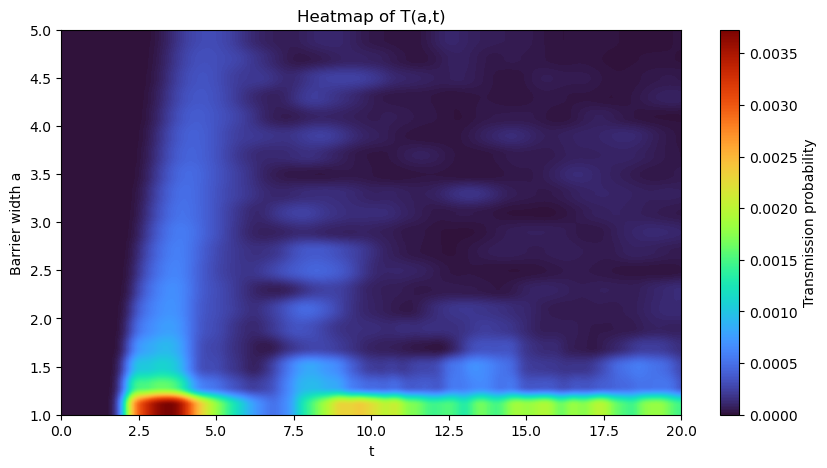

In [86]:
plt.figure(figsize=(10, 5))
plt.imshow(
    T_matrix,
    aspect="auto",
    origin="lower",
    extent=[time_array[0], time_array[-1], a_plot_values[0], a_plot_values[-1]],
    cmap="turbo"
)
plt.colorbar(label="Transmission probability")
plt.xlabel("t")
plt.ylabel("Barrier width a")
plt.title("Heatmap of T(a,t)")
plt.savefig("heatmap_of_transmission.pdf", bbox_inches="tight")
plt.show()

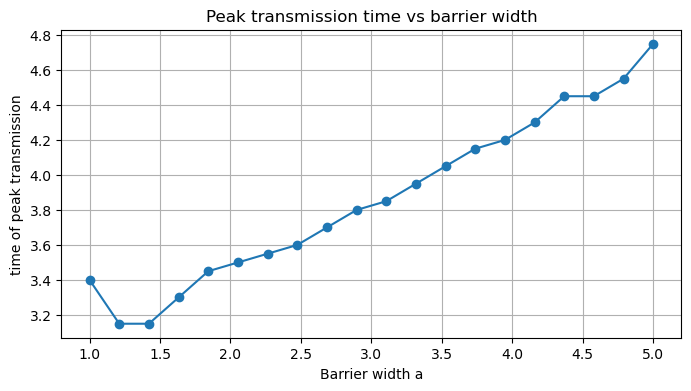

In [87]:
plt.figure(figsize=(8, 4))
plt.plot(a_values, T_peak_times, 'o-')
plt.xlabel("Barrier width a")
plt.ylabel("time of peak transmission")
plt.title("Peak transmission time vs barrier width")
plt.grid(True)
plt.savefig("peak_transmission_time_vs_barrier_width.pdf", bbox_inches="tight")
plt.show()

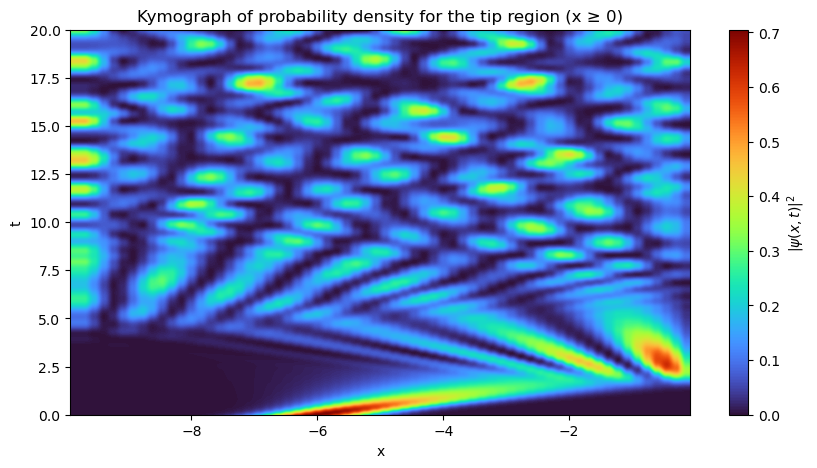

In [88]:
rho_list = []
time_list = []

for time, fields in storage.items():
    rho_list.append(probability_density(fields))
    time_list.append(time)

rho_array = np.array(rho_list)
time_array = np.array(time_list)

mask = (x <= 0)
x_cut = x[mask]
rho_array_cut = rho_array[:, mask]

plt.figure(figsize=(10, 5))
plt.imshow(
    rho_array_cut,
    aspect="auto",
    origin="lower",
    extent=[x_cut[0], x_cut[-1], time_array[0], time_array[-1]],
    cmap="turbo"
)
plt.colorbar(label=r"$|\psi(x,t)|^2$")
#plt.axvline(0, color="white", linestyle=":")
#plt.axvline(a, color="white", linestyle=":")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Kymograph of probability density for the tip region (x ≥ 0)")
plt.savefig("kymograph_tip_region.pdf", bbox_inches="tight")
plt.show()

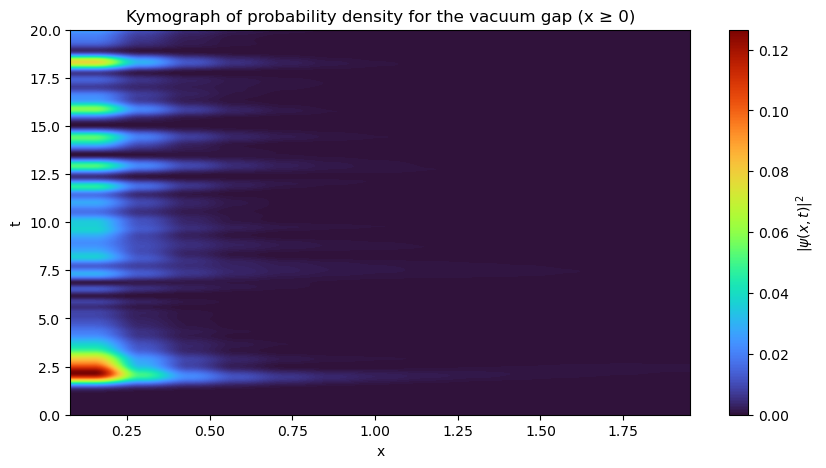

In [89]:
# ----- kymograph of probability density (from x = 0 to L) -----

rho_list = []
time_list = []

for time, fields in storage.items():
    rho_list.append(probability_density(fields))
    time_list.append(time)

rho_array = np.array(rho_list)
time_array = np.array(time_list)

mask = (x >= 0) & (x <= a)
x_cut = x[mask]
rho_array_cut = rho_array[:, mask]

plt.figure(figsize=(10, 5))
plt.imshow(
    rho_array_cut,
    aspect="auto",
    origin="lower",
    extent=[x_cut[0], x_cut[-1], time_array[0], time_array[-1]],
    cmap="turbo"
)
plt.colorbar(label=r"$|\psi(x,t)|^2$")
#plt.axvline(0, color="white", linestyle=":")
#plt.axvline(a, color="white", linestyle=":")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Kymograph of probability density for the vacuum gap (x ≥ 0)")
plt.savefig("kymograph_vacuum_gap.pdf", bbox_inches="tight")
plt.show()

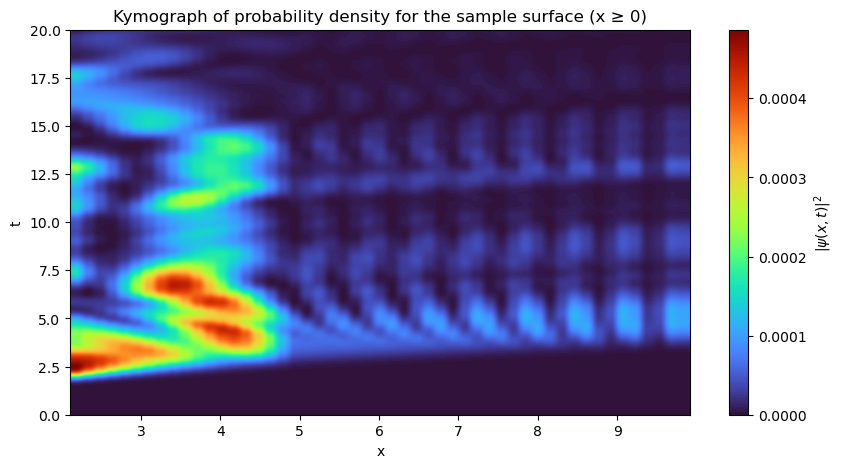

In [90]:
rho_list = []
time_list = []

for time, fields in storage.items():
    rho_list.append(probability_density(fields))
    time_list.append(time)

rho_array = np.array(rho_list)
time_array = np.array(time_list)

mask = (x >= a)
x_cut = x[mask]
rho_array_cut = rho_array[:, mask]

plt.figure(figsize=(10, 5))
plt.imshow(
    rho_array_cut,
    aspect="auto",
    origin="lower",
    extent=[x_cut[0], x_cut[-1], time_array[0], time_array[-1]],
    cmap="turbo"
)
plt.colorbar(label=r"$|\psi(x,t)|^2$")
#plt.axvline(0, color="white", linestyle=":")
#plt.axvline(a, color="white", linestyle=":")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Kymograph of probability density for the sample surface (x ≥ 0)")
plt.savefig("kymograph_sample_surface.pdf", bbox_inches="tight")
plt.show()